# Assignment 17: Support Vector Machines (SVM) ¶
##### Author: Md Ashhar Farooqui
##### Date: 24-07-2025

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Exploratory Data Analysis (EDA)
1.	Load the Mushroom dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.

In [2]:
# 1. Load the dataset
df = pd.read_csv('mushroom.csv')

In [3]:
# 2. Basic exploration
# print the first few rows of the dataset
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [4]:
# print the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [5]:
# print the summary statistics of the dataset
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


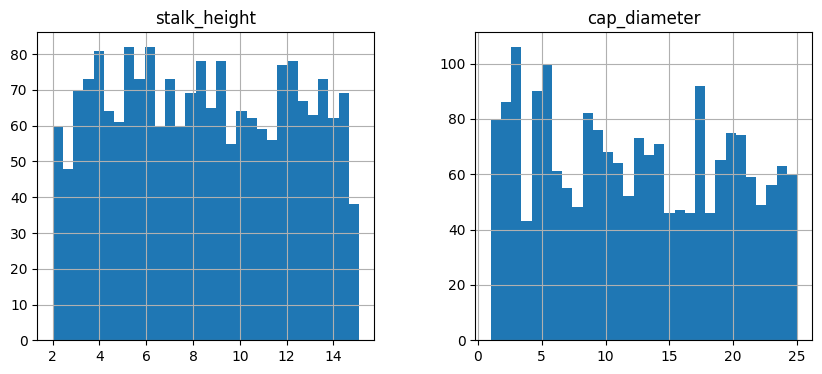

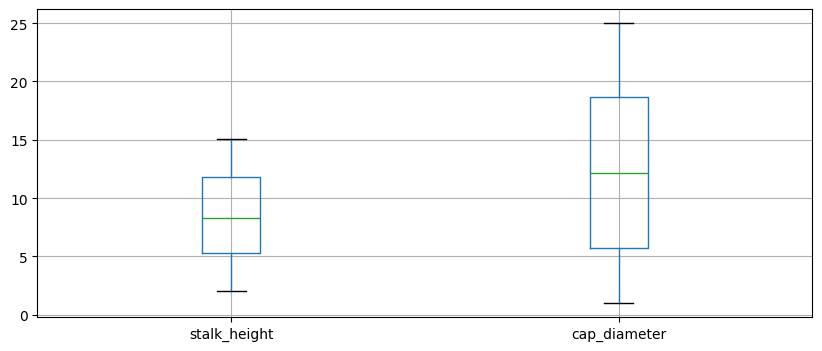

In [6]:
# 3. Histograms & box plots for numeric features
num_cols = ['stalk_height', 'cap_diameter']
df[num_cols].hist(bins=30, figsize=(10,4))
plt.show()
df.boxplot(column=num_cols, figsize=(10,4))
plt.show()

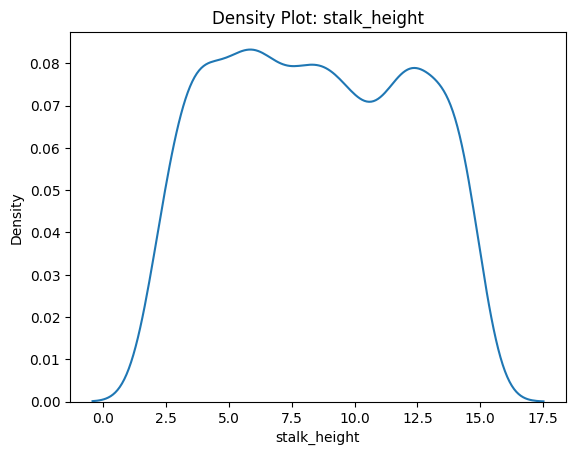

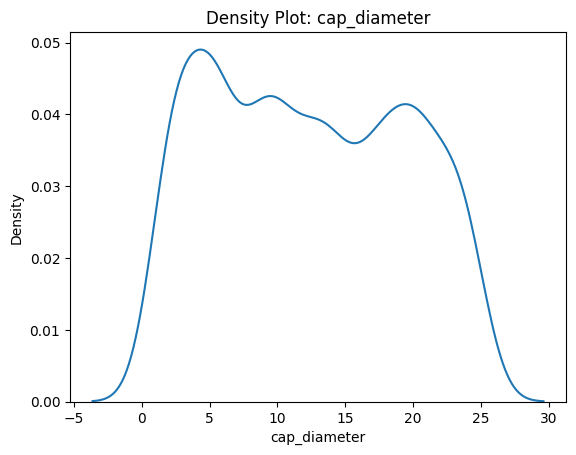

In [7]:
# 4. Density plots
for col in num_cols:
    sns.kdeplot(df[col])
    plt.title(f'Density Plot: {col}')
    plt.show()

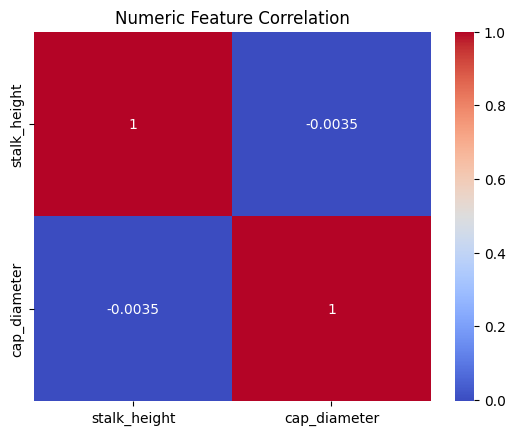

In [8]:
# 5. Correlation matrix
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Numeric Feature Correlation')
plt.show()

# Task 2: Data Preprocessing
1.	Encode categorical variables if necessary.
2.	Split the dataset into training and testing sets.


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Encode categorical variables
df_encoded = df.copy()
for col in df.columns:
    if df[col].dtype == 'object':
        df_encoded[col] = LabelEncoder().fit_transform(df[col])

In [10]:
# 2. Split into train/test
X = df_encoded.drop(['class'], axis=1)
y = df_encoded['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Shape of the training and testing sets
print(f'Training set shape: {X_train.shape}, {y_train.shape}')
print(f'Testing set shape: {X_test.shape}, {y_test.shape}')

Training set shape: (1600, 25), (1600,)
Testing set shape: (400, 25), (400,)


# Task 3: Data Visualization
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.	Visualize class distributions to gauge dataset balance or imbalance.


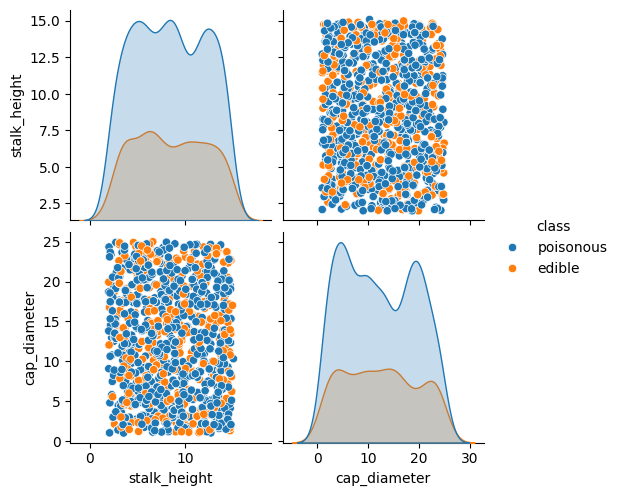

In [12]:
# 1. Pair plot for numeric features
sns.pairplot(df, hue='class', vars=num_cols)
plt.show()

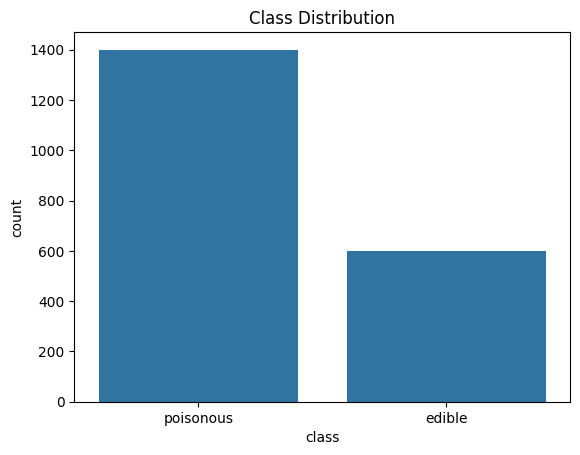

In [13]:
# 2. Class distribution
sns.countplot(x='class', data=df)
plt.title('Class Distribution')
plt.show()

# Task 4: SVM Implementation
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).


In [14]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Basic SVM classifier
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

SVC(random_state=42)

In [15]:
# 2. Predictions & evaluation
y_pred = svm.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[  0 133]
 [  0 267]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400

Accuracy: 0.6675


c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task 5: Visualization of SVM Results
1.	Visualize classification results on the testing data.


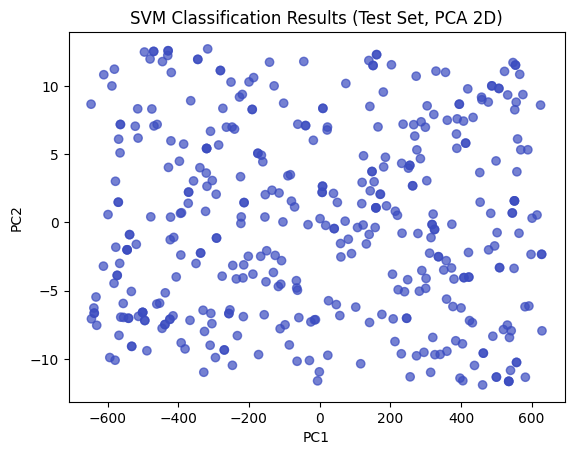

In [16]:
# Visualization of SVM Results
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)
plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_pred, cmap='coolwarm', alpha=0.7)
plt.title('SVM Classification Results (Test Set, PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Task 6: Parameter Tuning and Optimization
1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.


In [17]:
# Parameter Tuning and Optimization
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}
random_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=6, cv=3, random_state=42)
random_search.fit(X_train, y_train)
print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Params: {'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}
Best Score: 0.708125162496223


# Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.	Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.
3.	Discuss practical implications of SVM in real-world classification tasks.


## 1. Compare SVM performance 

In [18]:
# Comparison and Analysis
# Compare kernels
for kernel in ['linear', 'poly', 'rbf']:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    print(f"Kernel: {kernel}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print('-'*40)

Kernel: linear
Accuracy: 0.6675
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400

----------------------------------------
Kernel: poly
Accuracy: 0.6675
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400

----------------------------------------


c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: Unde

Kernel: rbf
Accuracy: 0.6675
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400

----------------------------------------


c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\py-3.13.3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 2. Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results

**Strengths:**
- SVMs are effective in high-dimensional spaces and can handle a large number of features, which is suitable for the mushroom dataset with many categorical variables.
- The kernel trick allows SVMs to model non-linear relationships, which is beneficial since the mushroom dataset likely contains complex, non-linear patterns.
- SVMs are robust to overfitting, especially in cases where the number of dimensions exceeds the number of samples.

**Weaknesses:**
- SVMs can be sensitive to the choice of kernel and hyperparameters (C, gamma), requiring careful tuning for optimal performance.
- Training time can be significant for large datasets, especially with non-linear kernels.
- SVMs do not provide direct probability estimates, which can be a limitation for some applications.
- Interpretation of SVM models is less intuitive compared to tree-based models.

**EDA and Visualization Insights:**
- The class distribution is relatively balanced, which is favorable for SVM classification.
- Numeric features like `stalk_height` and `cap_diameter` show some separation between classes, but overlap exists, justifying the use of non-linear kernels.
- Most features are categorical, and after encoding, SVM can efficiently separate classes if the data is linearly or non-linearly separable.

---

## 3. Discuss practical implications of SVM in real-world classification tasks

- **Generalization:** SVMs often generalize well to unseen data, making them suitable for real-world classification tasks where overfitting is a concern.
- **Versatility:** With different kernels, SVMs can be adapted to a wide variety of data types and distributions.
- **Scalability:** For very large datasets, SVMs may become computationally expensive; in such cases, approximate or linear SVMs, or alternative algorithms, may be preferred.
- **Feature Engineering:** SVMs require all features to be numeric, so categorical data must be encoded appropriately.
- **Applications:** SVMs are widely used in text classification, image recognition, bioinformatics, and other domains where high-dimensional data is common.
- **Interpretability:** SVMs are less interpretable than decision trees or logistic regression, which may be a drawback in domains requiring model transparency.

---